In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fftpack
from scipy.linalg import toeplitz
from scipy.signal import lfilter # 需要导入 lfilter 来进行 AR 滤波

In [2]:
class BearingAnalyzer:
    def __init__(self, fs=25600, xlim=100):
        """
        初始化分析器
        :param fs: 采样频率
        :param xlim: 频谱图显示的频率上限
        """
        self.fs = fs
        self.xlim = xlim

    def ar_prewhiten_demo(self, y, order=30):
        """简单的 AR 预白化实现（已针对长数据进行极速优化）"""
        # 1. 极速计算自相关：只计算前 order+1 个延迟点，避开 mode='full' 的计算黑洞
        r = np.zeros(order + 1)
        for k in range(order + 1):
            if k == 0:
                r[k] = np.dot(y, y)
            else:
                r[k] = np.dot(y[:-k], y[k:])
                
        # 2. 求解 Yule-Walker 方程 (Toeplitz 矩阵)
        try:
            R = toeplitz(r[:-1])
            R += np.eye(order) * 1e-9 # 正则化防止奇异
            a = np.linalg.solve(R, -r[1:])
            
            A = np.concatenate(([1.0], a))
            
            # 【关键修复1】预白化求残差是FIR滤波，AR系数 A 应当作为分子
            y_white = lfilter(A, [1.0], y)
            
            # 【关键修复2】print 必须写在 return 之前才能被执行
            print('预白化成功')
            return y_white   
        except Exception as e:
            # 捕获异常并打印具体原因，方便排错
            print(f'预白化失败，原因: {e}。返回原信号')
            return y
    def get_envelope(self, data, max_points=640000):
        """核心算法：提取包络谱"""
        # 截取信号并去直流
        xt = data[:max_points]
        xt=self.ar_prewhiten_demo(xt)
        xt=xt-np.mean(xt)
        ht = fftpack.hilbert(xt)
        at = np.sqrt(xt ** 2 + ht ** 2)
        at = at - np.mean(at)

        # FFT 变换
        n = len(at)
        am = np.abs(np.fft.fft(at))
        am = (am / n) * 2

        # 取正频率部分
        half_n = n // 2
        freq = np.fft.fftfreq(n, d=1 / self.fs)[:half_n]
        amp = am[:half_n]
        return freq, amp

    def plot_diagnostic(self, ax, freq, amp, motor_f, title, fault_type='BSF'):
        """绘图与理论频率标注"""
        # 绘制包络谱
        ax.plot(freq, amp, color='#1f77b4', lw=1.2, label='Envelope', zorder=3)
        ax.fill_between(freq, amp, color='#1f77b4', alpha=0.15)
        # 细节优化
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlim(0, self.xlim)
        # 自动调整Y轴刻度 (避开1Hz以内的低频干扰)
        valid_idx = freq > 1
        if any(valid_idx):
            ax.set_ylim(0, np.max(amp[valid_idx]) * 1.5)
        ax.legend(loc='upper right', fontsize=8)

    def process_folder(self, folder_path, fault_type='BSF'):
        """批量处理文件夹内的所有 CSV 文件"""
        files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
        cols = 3
        rows = (len(files) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), constrained_layout=True)
        axes = axes.flatten()
        for i, file_name in enumerate(files):
            # 1. 自动从文件名解析频率 (假设格式为 ..._40Hz_...)
            motor_f = float(file_name.split('Hz')[0].split('_')[-1])
            df = pd.read_csv(os.path.join(folder_path, file_name),usecols=['CH17'])
            data = df.iloc[:, 0].values
            # 3. 计算与绘图
            f, a = self.get_envelope(data)
            self.plot_diagnostic(axes[i], f, a, motor_f, file_name, fault_type)
            print(f"Processed: {file_name}")

        # 隐藏多余子图
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.show()


预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_+10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_-10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_0kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_+10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_-10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_0kN.csv


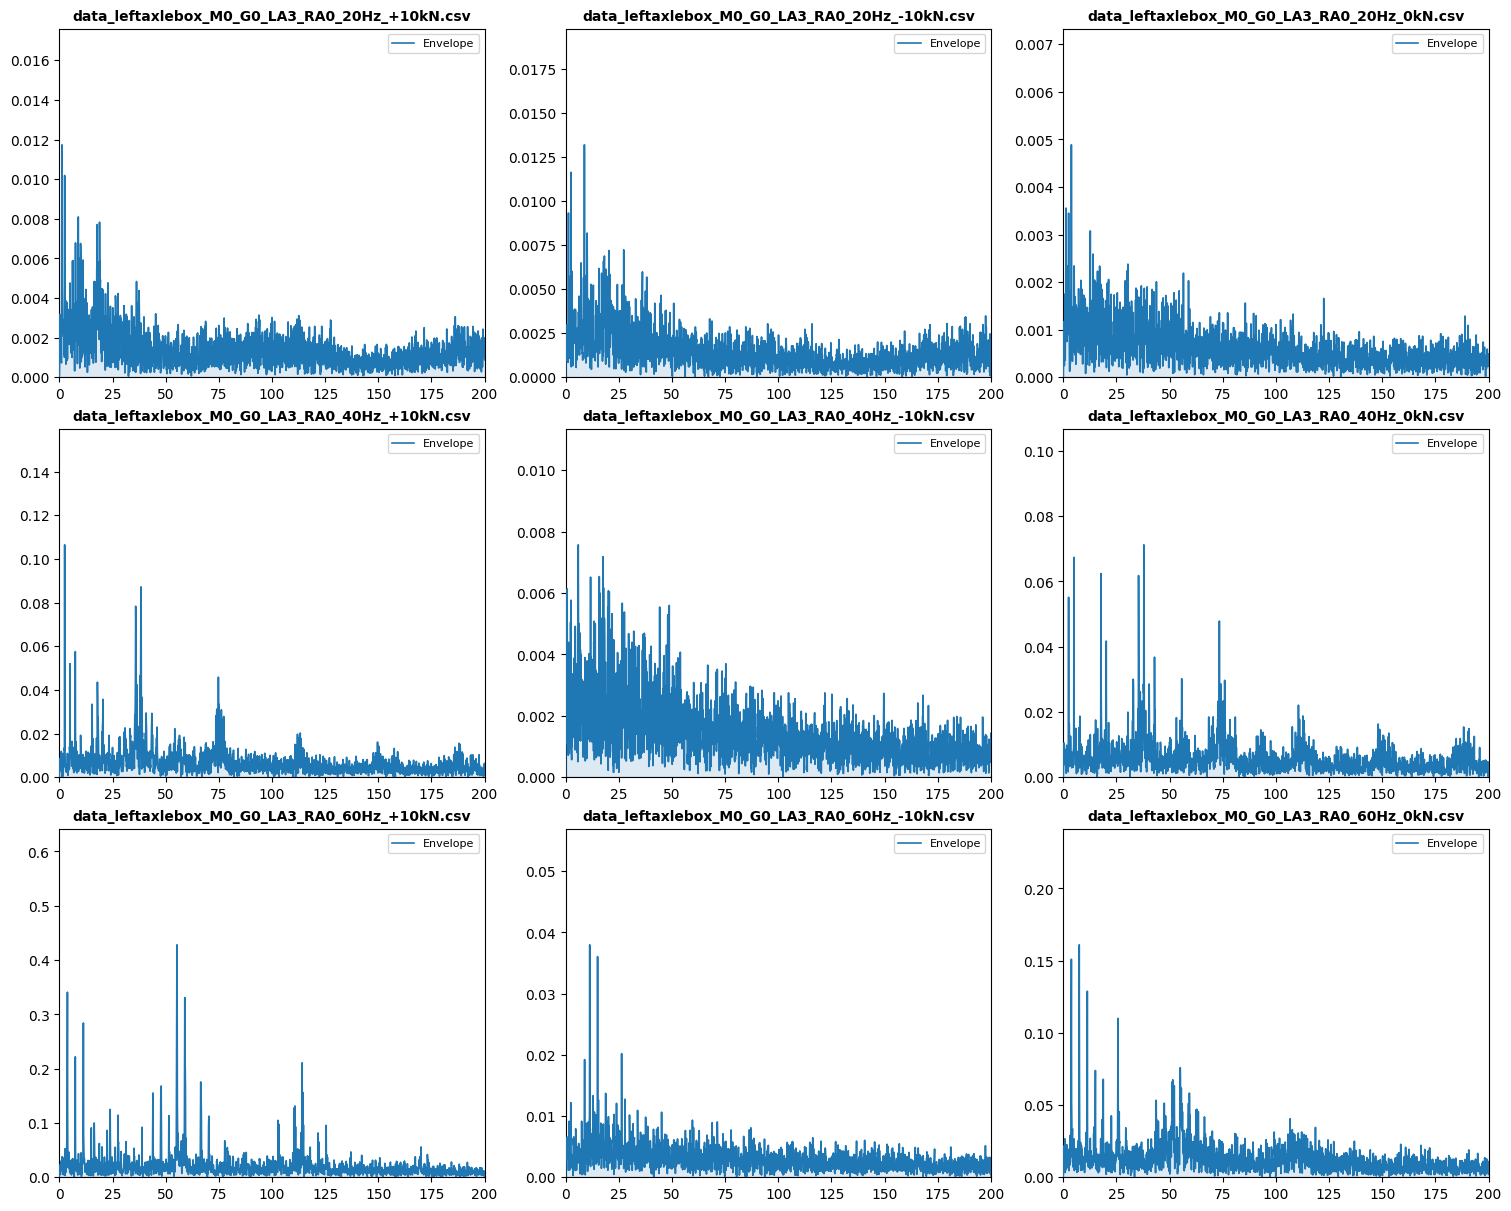

In [3]:
# --- 使用示例 ---
analyzer = BearingAnalyzer(fs=64000, xlim=200)
analyzer.process_folder('../数据集/BJTU/滚动体', fault_type='BSF')

预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_+10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_-10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_0kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_+10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_-10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_0kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_+10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_-10kN.csv
预白化成功
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_0kN.csv


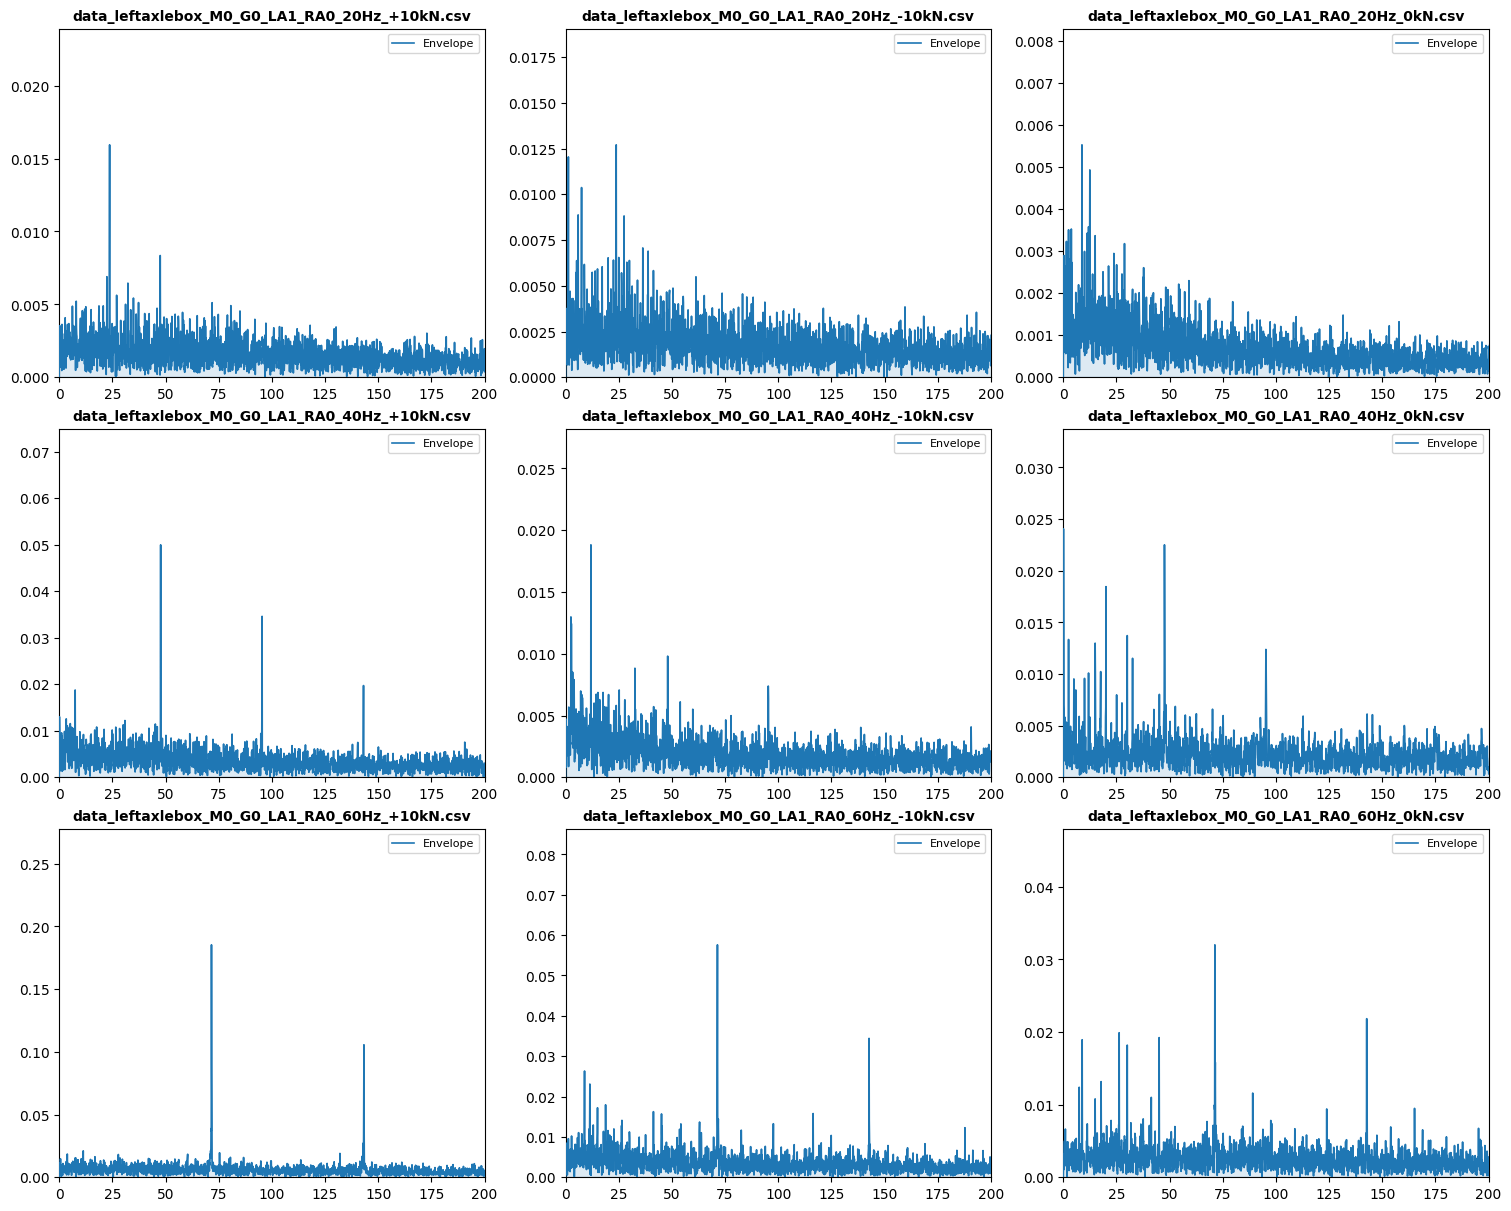

In [4]:
analyzer.process_folder('../数据集/BJTU/内圈', fault_type='BSF')